In [ ]:
# ============================================================================
# COMPLETE ANOVA ANALYSIS CODE FOR FLY MASS AND LENGTH DATA
# ============================================================================
# This code performs:
# 1. Male vs Female comparison within each group
# 2. Male vs Female total
# 3. All pairwise t-tests between groups
# ============================================================================

import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations

# ============================================================================
# STEP 1: LOAD YOUR DATA
# ============================================================================

raw_data = {
    'Axenic_early': {'Male': [0.743, 0.774, 0.732, 0.715], 'Female': [1.089, 1.149, 1.147, 1.1]},
    'Axenic_adult': {'Male': [0.788, 0.704, 0.854], 'Female': [1.206, 1.378, 1.3]},
    'Bacteria_early': {'Male': [0.953, 0.941, 0.861], 'Female': [1.383, 1.332, 1.478, 0.985]},
    'Reintroduce': {'Male': [0.748, 0.582, 0.751], 'Female': [1.253, 0.84, 1.171]},
    'Bacteria_adult': {'Male': [0.881, 0.73, 0.852], 'Female': [1.531, 1.124, 1.181]}
}

length_data = {
    'Axenic_early': {'Male': [2.568, 2.516, 2.574, 2.425, 2.09, 2.425, 2.626, 2.495, 2.564, 2.567, 2.434, 2.361, 2.323, 2.366, 2.426, 2.506, 2.23, 2.229, 2.376, 2.403], 'Female': [2.52, 2.672, 2.548, 2.658, 2.71, 2.689, 2.793, 2.734, 2.627, 2.691, 2.605, 3.035, 2.652, 2.967, 2.949, 2.8, 2.619, 3.164, 3.059, 2.969]},
    'Axenic_adult': {'Male': [2.108, 2.214, 2.019, 2.175, 2.188, 2.247, 2.43, 2.35, 2.338, 2.4, 2.586, 2.483, 2.488, 2.385, 2.395], 'Female': [2.723, 2.586, 2.641, 2.801, 2.9, 2.889, 2.972, 2.994, 3.059, 2.991, 2.758, 2.88, 2.86, 2.785, 2.798]},
    'Bacteria_early': {'Male': [2.582, 2.406, 2.519, 2.622, 2.559, 2.521, 2.63, 2.581, 2.524, 2.563, 2.235, 2.378, 2.379, 2.437, 2.424], 'Female': [2.875, 2.945, 2.902, 2.692, 2.822, 3.05, 3.008, 3.151, 3.167, 2.94, 2.768, 2.925, 2.869, 2.923, 2.865, 2.59, 2.818, 2.89, 2.59, 2.769]},
    'Reintroduce': {'Male': [2.056, 2.244, 2.312, 2.083, 2.197, 2.076, 2.07, 1.951, 1.962, 1.964, 2.282, 2.041, 2.09, 2.354, 1.958], 'Female': [2.57, 2.907, 2.458, 2.368, 2.701, 2.585, 2.468, 2.464, 2.476, 2.499, 2.393, 2.457, 2.798, 2.524, 2.848]},
    'Bacteria_adult': {'Male': [2.193, 2.24, 2.134, 2.537, 2.293, 2.575, 2.141, 2.237, 2.132, 2.338, 2.237, 2.132, 2.033, 2.246, 2.311], 'Female': [2.705, 2.896, 3.142, 2.602, 2.528, 2.819, 2.656, 2.798, 2.66, 2.935, 2.932, 2.733, 2.844, 2.983, 2.818]}
}

# Create dataframe
rows = []
for group in raw_data.keys():
    for sex in ['Male', 'Female']:
        weights = raw_data[group][sex]
        lengths = length_data[group][sex]
        for i, (w, l) in enumerate(zip(weights, lengths)): #zip stops at the shorter list, so only the first 3–4 lengths per group entered the test, add to slove bug
            rows.append({'Group': group, 'Sex': sex, 'Weight': w, 'Length': l})

df = pd.DataFrame(rows)
groups = ['Axenic_early', 'Axenic_adult', 'Bacteria_early', 'Reintroduce', 'Bacteria_adult']

# ============================================================================
# STEP 2: MALE vs FEMALE COMPARISON (within each group)
# ============================================================================
# =========
# For weight,
#Mann‑Whitney U doesn't really work for weight. 
# When both groups have only 3 observations, 
# the smallest possible two‑sided p‑value is 0.1. 
# Total number of ways to assign 6 values into two groups of 3 = choose(6,3) = 20. 
# If all values of group A are smaller than all values of group B, the U statistic is 0. 
# The probability of observing U = 0 under the null is 1/20 = 0.05. For a two‑sided test, 
# you double that → p = 0.1. p < 0.05 mean significant, it will not work.
# =========

groups = list(raw_data.keys())
rows = []
for group in groups:
    for sex in ["Male", "Female"]:
        for l in raw_data[group][sex]:
            rows.append({"Group": group, "Sex": sex, "weight": l})

df_weight = pd.DataFrame(rows)

print("\n--- WEIGHT ONLY ---")
print(f"{'Group':<20} {'Male':>8} {'Female':>8} {'p-value':>10} {'Sig':>5}")
print('-' * 55)
for group in groups:
    male = df_weight[(df_weight['Group']==group) & (df_weight['Sex']=='Male')]['weight']
    female = df_weight[(df_weight['Group']==group) & (df_weight['Sex']=='Female')]['weight']
    # u_stat_weight, p = stats.mannwhitneyu(male, female, alternative='two-sided')
    t, p = stats.ttest_ind(male, female)
    sig = '*' if p < 0.05 else ''
    print(f"{group:<20} {male.mean():>8.3f} {female.mean():>8.3f} {p:>10.4f} {sig:>5}")

print("OVERALL MALE vs FEMALE (pooled across all groups)")
male_weight = df_weight[df_weight['Sex'] == 'Male']['weight']
female_weight = df_weight[df_weight['Sex'] == 'Female']['weight']
t_weight, p_weight = stats.ttest_ind(male_weight, female_weight, equal_var=False)  # Welch's test
#u_stat_weight, p_weight = stats.mannwhitneyu(male_weight, female_weight, alternative='two-sided')
print(f"\nWEIGHT (pooled): Male n={len(male_weight)}, mean={male_weight.mean():.3f}; Female n={len(female_weight)}, mean={female_weight.mean():.3f}")
print(f"  t = {t_weight:.3f}, p = {p_weight:.4f} {'*' if p_weight < 0.05 else ''}")

# =========
# For Length
# =========
groups = list(length_data.keys())
rows = []
for group in groups:
    for sex in ["Male", "Female"]:
        for l in length_data[group][sex]:
            rows.append({"Group": group, "Sex": sex, "Length": l})

df_length = pd.DataFrame(rows)

print("\n--- LENGTH ONLY ---")
print(f"{'Group':<20} {'Male':>8} {'Female':>8} {'p-value':>10} {'Sig':>5}")
print('-' * 55)
for group in groups:
    male = df_length[(df_length['Group']==group) & (df_length['Sex']=='Male')]['Length']
    female = df_length[(df_length['Group']==group) & (df_length['Sex']=='Female')]['Length']
    t, p = stats.ttest_ind(male, female, equal_var=False)  # Welch's t-test handles unequal n
    sig = '*' if p < 0.05 else ''
    print(f"{group:<20} {male.mean():>8.3f} {female.mean():>8.3f} {p:>10.4f} {sig:>5}")

print("OVERALL MALE vs FEMALE (pooled across all groups)")
male_length = df_length[df_length['Sex'] == 'Male']['Length']
female_length = df_length[df_length['Sex'] == 'Female']['Length']
u_stat_length, p_length = stats.mannwhitneyu(male_length, female_length, alternative='two-sided')
t_length, p = stats.ttest_ind(male_length, female_length, equal_var=False)
print(f"\nLENGTH (pooled): Male n={len(male_length)}, mean={male_length.mean():.3f}; Female n={len(female_length)}, mean={female_length.mean():.3f}")
print(f" t={t_length:.3f}, u = {u_stat_length:.3f}, pt = {p:.4f}, p = {p_length:.4f} {'*' if p_length < 0.05 else ''}")

# ============================================================================
# STEP 3: PAIRWISE T-TESTS (all group comparisons)
# ============================================================================
print("\n" + "=" * 70)
print("3. PAIRWISE T-TESTS")
print("=" * 70)

for sex in ['Male', 'Female']:
    for measure in ['Weight', 'Length']:
        print(f"\n--- {sex.upper()}S - {measure.upper()} ---")
        sex_data = df[df['Sex'] == sex]
        
        for g1, g2 in combinations(groups, 2):
            data1 = sex_data[sex_data['Group'] == g1][measure]
            data2 = sex_data[sex_data['Group'] == g2][measure]
            t, p = stats.ttest_ind(data1, data2)
            sig = '*' if p < 0.05 else ''
            if p < 0.05:  # Only print significant results
                print(f"  {g1} vs {g2}: p = {p:.4f} {sig}")

print("\n" + "=" * 70)
print("DONE! (* indicates p < 0.05)")
print("=" * 70)

print("3. PAIRWISE U-TESTS (Mann-Whitney U)")

for sex in ['Male', 'Female']:
    for measure in ['Weight', 'Length']:
        print(f"\n--- {sex.upper()}S - {measure.upper()} ---")
        sex_data = df[df['Sex'] == sex]
        
        for g1, g2 in combinations(groups, 2):
            data1 = sex_data[sex_data['Group'] == g1][measure]
            data2 = sex_data[sex_data['Group'] == g2][measure]
            u_stat, p = stats.mannwhitneyu(data1, data2, alternative='two-sided')
            print(f"  {g1} vs {g2}: p = {p:.4f} {sig}")

# ============================================================================
# STEP 5: MW tes leat (all group comparisons) SEARCH to DO Later
# ============================================================================
# print("\n" + "=" * 70)
# print("3. PAIRWISE T-TESTS")
# print("=" * 70)

# for sex in ['Male', 'Female']:
#     for measure in ['Weight', 'Length']:
#         print(f"\n--- {sex.upper()}S - {measure.upper()} ---")
#         sex_data = df[df['Sex'] == sex]
        
#         for g1, g2 in combinations(groups, 2):
#             data1 = sex_data[sex_data['Group'] == g1][measure]
#             data2 = sex_data[sex_data['Group'] == g2][measure]
#             t, p = stats.ttest_ind(data1, data2)
#             sig = '*' if p < 0.05 else ''
#             if p < 0.05:  # Only print significant results
#                 print(f"  {g1} vs {g2}: p = {p:.4f} {sig}")

# print("\n" + "=" * 70)
# print("DONE! (* indicates p < 0.05)")
# print("=" * 70)


--- WEIGHT ONLY ---
Group                    Male   Female    p-value   Sig
-------------------------------------------------------
Axenic_early            0.741    1.121     0.0000     *
Axenic_adult            0.782    1.295     0.0015     *
Bacteria_early          0.918    1.294     0.0336     *
Reintroduce             0.694    1.088     0.0461     *
Bacteria_adult          0.821    1.279     0.0278     *
OVERALL MALE vs FEMALE (pooled across all groups)

WEIGHT (pooled): Male n=16, mean=0.788; Female n=17, mean=1.215
  t = -8.741, p = 0.0000 *

--- LENGTH ONLY ---
Group                    Male   Female    p-value   Sig
-------------------------------------------------------
Axenic_early            2.425    2.773     0.0000     *
Axenic_adult            2.320    2.842     0.0000     *
Bacteria_early          2.491    2.878     0.0000     *
Reintroduce             2.109    2.568     0.0000     *
Bacteria_adult          2.252    2.803     0.0000     *
OVERALL MALE vs FEMALE (pooled a

In [1]:
#!/usr/bin/env python3
"""
Body Size Analysis Code
=======================
Load your mass_length.xlsx and analyze Male vs Female within each treatment group.

Author: For Tian (Ludington Lab)
"""

import pandas as pd
import numpy as np
from scipy import stats

# =============================================================================
# 1. LOAD YOUR DATA
# =============================================================================
file_path = 'mass_length.xlsx'  # Change this to your file path

# Load sheets
length_df = pd.read_excel(file_path, sheet_name='Length')
mass_df = pd.read_excel(file_path, sheet_name='weight_GF_B_GFB')

print("Columns in Length sheet:", length_df.columns.tolist())
print("Columns in Mass sheet:", mass_df.columns.tolist()[:11])

# =============================================================================
# 2. DEFINE COLUMNS
# =============================================================================
length_cols = [
    'axenic early ecolsion M', 'axenic early ecolsion F',
    'axenic adult M', 'axenic adult F',
    'Bacteria early ecolsion M', 'Bacteria early ecolsion F',
    'Reintroduce M', 'Reintroduce F',
    'Bacteria adult M', 'Bacteria adult F'
]

# =============================================================================
# 3. EXTRACT DATA
# =============================================================================
# Length data - remove outliers < 1.5 mm
length_data = {}
for col in length_cols:
    values = pd.to_numeric(length_df[col], errors='coerce').dropna()
    values = values[values >= 1.5]  # Remove outliers
    length_data[col] = values
    print(f"Length - {col}: n = {len(values)}")

# Mass data - only first 4 rows have actual data
mass_data = {}
for col in length_cols:
    if col in mass_df.columns:
        values = pd.to_numeric(mass_df[col].iloc[:4], errors='coerce').dropna()
        mass_data[col] = values
        print(f"Mass - {col}: n = {len(values)}")

# =============================================================================
# 4. COMPARE MALE vs FEMALE WITHIN EACH GROUP
# =============================================================================
def compare_male_female(male_data, female_data, group_name, measure=''):
    """Compare male vs female using Mann-Whitney U test"""
    stat, pval = stats.mannwhitneyu(male_data, female_data, alternative='two-sided')
    diff = female_data.mean() - male_data.mean()
    pct = (female_data.mean() / male_data.mean() - 1) * 100

    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'

    print(f"\n{group_name} ({measure}):")
    print(f"  Males:   n={len(male_data):2d}, mean={male_data.mean():.3f}")
    print(f"  Females: n={len(female_data):2d}, mean={female_data.mean():.3f}")
    print(f"  Diff (F-M): {diff:.3f} ({pct:.1f}%)")
    print(f"  Mann-Whitney U = {stat:.1f}, p = {pval:.4f} {sig}")

# Groups to compare
groups = [
    ('axenic early ecolsion', 'Axenic Early Eclosion'),
    ('axenic adult', 'Axenic Adult (B2_conA)'),
    ('Bacteria early ecolsion', 'Bacteria Early Eclosion (A_inoA)'),
    ('Reintroduce', 'Reintroduce (B1_reintro)'),
    ('Bacteria adult', 'Bacteria Adult'),
]

print("\n" + "="*60)
print("BODY LENGTH COMPARISONS")
print("="*60)
for col_prefix, name in groups:
    compare_male_female(length_data[f'{col_prefix} M'], 
                       length_data[f'{col_prefix} F'], 
                       name, 'Length mm')

print("\n" + "="*60)
print("BODY MASS COMPARISONS")
print("="*60)
for col_prefix, name in groups:
    if f'{col_prefix} M' in mass_data and f'{col_prefix} F' in mass_data:
        if len(mass_data[f'{col_prefix} M']) >= 2 and len(mass_data[f'{col_prefix} F']) >= 2:
            compare_male_female(mass_data[f'{col_prefix} M'], 
                               mass_data[f'{col_prefix} F'], 
                               name, 'Mass mg')

# =============================================================================
# 5. OPTIONAL: POOL GROUPS AND COMPARE
# =============================================================================
print("\n" + "="*60)
print("POOLED ANALYSIS: AXENIC vs BACTERIA")
print("="*60)

# Pool axenic (early + adult)
axenic_M = pd.concat([length_data['axenic early ecolsion M'], 
                      length_data['axenic adult M']])
axenic_F = pd.concat([length_data['axenic early ecolsion F'], 
                      length_data['axenic adult F']])

# Pool bacteria (early + adult) - EXCLUDING reintroduce
bacteria_M = pd.concat([length_data['Bacteria early ecolsion M'], 
                        length_data['Bacteria adult M']])
bacteria_F = pd.concat([length_data['Bacteria early ecolsion F'], 
                        length_data['Bacteria adult F']])

print("\nPooled Axenic (early + adult):")
compare_male_female(axenic_M, axenic_F, 'Axenic Pooled', 'Length mm')

print("\nPooled Bacteria (early + adult, excluding reintroduce):")
compare_male_female(bacteria_M, bacteria_F, 'Bacteria Pooled', 'Length mm')

# Compare Axenic vs Bacteria within each sex
print("\n" + "="*60)
print("AXENIC vs BACTERIA (within sex)")
print("="*60)

stat, pval = stats.mannwhitneyu(axenic_M, bacteria_M, alternative='two-sided')
print(f"\nMALES: Axenic (n={len(axenic_M)}, mean={axenic_M.mean():.3f}) vs Bacteria (n={len(bacteria_M)}, mean={bacteria_M.mean():.3f})")
print(f"  Mann-Whitney U = {stat:.1f}, p = {pval:.4f}")

stat, pval = stats.mannwhitneyu(axenic_F, bacteria_F, alternative='two-sided')
print(f"\nFEMALES: Axenic (n={len(axenic_F)}, mean={axenic_F.mean():.3f}) vs Bacteria (n={len(bacteria_F)}, mean={bacteria_F.mean():.3f})")
print(f"  Mann-Whitney U = {stat:.1f}, p = {pval:.4f}")


Columns in Length sheet: ['Unnamed: 0', 'axenic early ecolsion M', 'axenic early ecolsion F', 'axenic adult M', 'axenic adult F', 'Bacteria early ecolsion M', 'Bacteria early ecolsion F', 'Reintroduce M', 'Reintroduce F', 'Bacteria adult M', 'Bacteria adult F']
Columns in Mass sheet: ['Unnamed: 0', 'axenic early ecolsion M', 'axenic early ecolsion F', 'axenic adult M', 'axenic adult F', 'Bacteria early ecolsion M', 'Bacteria early ecolsion F', 'Reintroduce M', 'Reintroduce F', 'Bacteria adult M', 'Bacteria adult F']
Length - axenic early ecolsion M: n = 23
Length - axenic early ecolsion F: n = 23
Length - axenic adult M: n = 18
Length - axenic adult F: n = 18
Length - Bacteria early ecolsion M: n = 18
Length - Bacteria early ecolsion F: n = 21
Length - Reintroduce M: n = 16
Length - Reintroduce F: n = 16
Length - Bacteria adult M: n = 16
Length - Bacteria adult F: n = 16
Mass - axenic early ecolsion M: n = 4
Mass - axenic early ecolsion F: n = 4
Mass - axenic adult M: n = 3
Mass - axen

In [1]:
# ============================================================================
# BODY SIZE: 
# Above code do compared body size among adult groups (AA, CAA, and CA). Initial t-test analysis suggested that CAA 
# flies were significantly smaller than CA flies in body length (2.568 ± 0.043 mm vs 2.803 ± 0.042 mm, p = 0.0066 for females). 
# However, given the small sample sizes (n = 3 per group), we applied the Mann-Whitney U test, which does not assume normality and is more appropriate for small samples. 
# Since with n = 3 per group, the minimum achievable two-sided p-value is 0.10, limiting statistical power to detect subtle effects, 
# One-sided Mann-Whitney U tests are also used for analysis. Both U tests revealed no significant differences among treatment groups (all p ≥ 0.05).
# Ok. It is little mess. A little truncated the body-length dataset (the data-merging due to one flies too light to measure by own, so 5 flies measure together.
# since to reduced the length measurements to the number of mass pools, 3–4 per group). 
# We use Kruskal–Wallis omnibus tests within each sex and age, Holm-corrected pairwise Welch's t-tests, Shapiro–Wilk and Levene assumption checks, and effect sizes with 95% confidence intervals. 
# Now it is cleaner, and it still give the same result that
# Our original analysis applied three tests to the same contrasts — t-tests (for effect-size estimation at small n), 
# Mann–Whitney U tests (as a distribution-free check that does not assume normality), 
# and one-sided U tests (to salvage statistical power at n = 3, where the minimum two-sided p-value is 0.10). 
# Now OMNIBUS + HOLM ANALYSIS cleaner. 
# mass_length.xlsx (sheets 'Length' rows 2-21 and 'weight_GF_B_GFB' rows 2-5).
# Requires: numpy, scipy, pandas. Two-sided, alpha = 0.05.
#
# Design:
#   1. Sex contrast (Female vs Male) within each group:
#      Welch's t (primary) + Mann-Whitney U (sensitivity), Cohen's d, 95% CI.
#   2. Treatment effect within each sex x age:
#      Kruskal-Wallis omnibus (primary) + one-way ANOVA , then Holm-corrected pairwise Welch's t ONLY as follow-up.
#   3. My old pairwise section for comparison.
#
# Small-sample caveat (printed below and stated in the manuscript):
#   mass = 5-fly pools, n = 3-4 per group x sex -> rank tests cannot reach
#   n = 15-20 per group x sex 
# total 165 length data point
# 33 weight for single flies not able to measure, we measure 5 flies and take the average.
# ============================================================================

import numpy as np
import pandas as pd
from scipy import stats
from itertools import combinations

# ---------------------------------------------------------------------------
# DATA (each mass value = average mass of a 5-fly pool, mg; each length value = one individual fly, mm)
# ---------------------------------------------------------------------------
weight_data = {
    'NEC': {'Male': [0.953, 0.941, 0.861],            'Female': [1.383, 1.332, 1.478, 0.985]},
    'NEA': {'Male': [0.743, 0.774, 0.732, 0.715],     'Female': [1.089, 1.149, 1.147, 1.1]},
    'CA':  {'Male': [0.881, 0.73, 0.852],             'Female': [1.531, 1.124, 1.181]},
    'CAA': {'Male': [0.748, 0.582, 0.751],            'Female': [1.253, 0.84, 1.171]},
    'AA':  {'Male': [0.788, 0.704, 0.854],            'Female': [1.206, 1.378, 1.3]},
}
length_data = {
    'NEC': {'Male': [2.582, 2.406, 2.519, 2.622, 2.559, 2.521, 2.63, 2.581, 2.524, 2.563, 2.235, 2.378, 2.379, 2.437, 2.424],
            'Female': [2.875, 2.945, 2.902, 2.692, 2.822, 3.05, 3.008, 3.151, 3.167, 2.94, 2.768, 2.925, 2.869, 2.923, 2.865, 2.59, 2.818, 2.89, 2.59, 2.769]},
    'NEA': {'Male': [2.568, 2.516, 2.574, 2.425, 2.09, 2.425, 2.626, 2.495, 2.564, 2.567, 2.434, 2.361, 2.323, 2.366, 2.426, 2.506, 2.23, 2.229, 2.376, 2.403],
            'Female': [2.52, 2.672, 2.548, 2.658, 2.71, 2.689, 2.793, 2.734, 2.627, 2.691, 2.605, 3.035, 2.652, 2.967, 2.949, 2.8, 2.619, 3.164, 3.059, 2.969]},
    'CA':  {'Male': [2.193, 2.24, 2.134, 2.537, 2.293, 2.575, 2.141, 2.237, 2.132, 2.338, 2.237, 2.132, 2.033, 2.246, 2.311],
            'Female': [2.705, 2.896, 3.142, 2.602, 2.528, 2.819, 2.656, 2.798, 2.66, 2.935, 2.932, 2.733, 2.844, 2.983, 2.818]},
    'CAA': {'Male': [2.056, 2.244, 2.312, 2.083, 2.197, 2.076, 2.07, 1.951, 1.962, 1.964, 2.282, 2.041, 2.09, 2.354, 1.958],
            'Female': [2.57, 2.907, 2.458, 2.368, 2.701, 2.585, 2.468, 2.464, 2.476, 2.499, 2.393, 2.457, 2.798, 2.524, 2.848]},
    'AA':  {'Male': [2.108, 2.214, 2.019, 2.175, 2.188, 2.247, 2.43, 2.35, 2.338, 2.4, 2.586, 2.483, 2.488, 2.385, 2.395],
            'Female': [2.723, 2.586, 2.641, 2.801, 2.9, 2.889, 2.972, 2.994, 3.059, 2.991, 2.758, 2.88, 2.86, 2.785, 2.798]},
}
# To load from the Excel file also work, but I have different label in excel, so make it same as mansxript here to make life easier
#   raw = pd.read_excel('mass_length.xlsx', sheet_name='Length', header=0, nrows=20)
#   wraw = pd.read_excel('mass_length.xlsx', sheet_name='weight_GF_B_GFB', header=0, nrows=4)

GROUPS = list(weight_data.keys())          # NEC, NEA, CA, CAA, AA
ADULTS = ['CA', 'CAA', 'AA']
NEWLY  = ['NEC', 'NEA']

# ---------------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------------
def cohen_d(a, b):
    """Cohen's d, pooled SD, mean(a) - mean(b)."""
    na, nb = len(a), len(b)
    s = np.sqrt(((na-1)*np.var(a, ddof=1) + (nb-1)*np.var(b, ddof=1)) / (na+nb-2))
    return (np.mean(a) - np.mean(b)) / s

def welch_ci(a, b, conf=0.95):
    """Mean difference (a-b), 95% CI, Welch-Satterthwaite df."""
    va, vb = np.var(a, ddof=1)/len(a), np.var(b, ddof=1)/len(b)
    diff = np.mean(a) - np.mean(b)
    se = np.sqrt(va + vb)
    dfw = (va + vb)**2 / (va**2/(len(a)-1) + vb**2/(len(b)-1))
    tc = stats.t.ppf(1-(1-conf)/2, dfw)
    return diff, diff-tc*se, diff+tc*se

def holm(pvals):
    """Holm-Bonferroni adjusted p-values."""
    p = np.asarray(pvals, float); order = np.argsort(p); m = len(p)
    adj = np.empty(m); running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (m-rank)*p[idx])
        adj[idx] = min(1.0, running)
    return adj

# ---------------------------------------------------------------------------
# 1. DATA AUDIT + SMALL-SAMPLE CAVEAT
# ---------------------------------------------------------------------------
print("=" * 74)
print("1. DATA AUDIT")
print("=" * 74)
n_len = sum(len(v) for g in length_data.values() for v in g.values())
n_wt = sum(len(v) for g in weight_data.values() for v in g.values())
print(f"Individual length measurements: {n_len} (expected 165)")
print(f"5-fly mass pools:               {n_wt} (expected 33; ~{n_wt*5} flies weighed)")
for g in GROUPS:
    print(f"  {g:4s} length n(M/F) = {len(length_data[g]['Male'])}/{len(length_data[g]['Female'])}"
          f" | mass pools n(M/F) = {len(weight_data[g]['Male'])}/{len(weight_data[g]['Female'])}")
print("\nCAVEAT: mass pools n=3-4/cell -> rank tests min two-sided p=0.1 at n=3v3;")
print("        mass results are reported with this power limitation.")
print("        length n=15-20/cell -> adequately powered.")
print("From NEC we have 15/20. More Bacteria early ecolsion F sample than M one because during experiment, Trial 2 A (embryonic inoculation), Male don't have enough male flies. It is in data sheet. You can't make flies give brith to same amount of male and female.")

# ---------------------------------------------------------------------------
# 2. ASSUMPTION CHECKS, check each treatment and group distrubution. 
# ---------------------------------------------------------------------------
print("\n" + "=" * 74)
print("2. ASSUMPTION CHECKS (Shapiro-Wilk per cell; Levene across adult groups)")
print("=" * 74)
for name, dat in [("length", length_data), ("mass (5-fly pools)", weight_data)]:
    print(f"\n--- {name} ---")
    for g in GROUPS:
        for sex in ["Male", "Female"]:
            x = np.asarray(dat[g][sex])
            W, p = stats.shapiro(x)
            flag = "" if p > 0.05 else "  <-- non-normal"
            print(f"  {g:4s} {sex:7s} n={len(x):2d}  W={W:.3f} p={p:.4f}{flag}")
    for sex in ["Male", "Female"]:
        samps = [np.asarray(dat[g][sex]) for g in ADULTS]
        L, p = stats.levene(*samps, center='median')
        print(f"  Levene (adults, {sex}): W={L:.3f} p={p:.4f}")

# ---------------------------------------------------------------------------
# 3. SEX CONTRASTS: Female vs Male within each group
# ---------------------------------------------------------------------------
print("\n" + "=" * 74)
print("3. SEX CONTRASTS (Female - Male, two-sided)")
print("=" * 74)
for name, dat, unit in [("LENGTH (mm)", length_data, "mm"), ("MASS (mg/fly, 5-fly pools)", weight_data, "mg")]:
    print(f"\n--- {name} ---")
    print(f"{'grp':5s} {'nM':>3s} {'nF':>3s} {'meanM':>7s} {'meanF':>7s} {'diff':>7s} {'95% CI':>17s} {'t':>7s} {'p_t':>10s} {'d':>6s} {'p_U':>8s}")
    for g in GROUPS:
        m, f = np.asarray(dat[g]['Male']), np.asarray(dat[g]['Female'])
        t, p_t = stats.ttest_ind(f, m, equal_var=False)
        u, p_u = stats.mannwhitneyu(f, m, alternative='two-sided')
        d = cohen_d(f, m)
        diff, lo, hi = welch_ci(f, m)
        print(f"{g:5s} {len(m):3d} {len(f):3d} {m.mean():7.3f} {f.mean():7.3f} {diff:7.3f} [{lo:6.3f},{hi:6.3f}] {t:7.2f} {p_t:10.2e} {d:6.2f} {p_u:8.2e}")

# ---------------------------------------------------------------------------
# 4. OMNIBUS TREATMENT TESTS + HOLM-CORRECTED PAIRWISE (primary analysis)
# ---------------------------------------------------------------------------
print("\n" + "=" * 74)
print("4. OMNIBUS (Kruskal-Wallis primary; ANOVA reference) + HOLM PAIRWISE")
print("=" * 74)
for name, dat, unit in [("LENGTH (mm)", length_data, "mm"), ("MASS (mg/fly, 5-fly pools)", weight_data, "mg")]:
    for age, grps in [("newly eclosed", NEWLY), ("adult (5-7 d)", ADULTS)]:
        for sex in ["Male", "Female"]:
            samps = {g: np.asarray(dat[g][sex]) for g in grps}
            H, p_kw = stats.kruskal(*samps.values())
            F, p_an = stats.f_oneway(*samps.values())
            allv = np.concatenate(list(samps.values()))
            ss_tot = ((allv - allv.mean())**2).sum()
            eta2 = sum(len(v)*(v.mean()-allv.mean())**2 for v in samps.values()) / ss_tot
            print(f"\n--- {name} | {age} | {sex} | n={{ {', '.join(f'{g}: {len(v)}' for g, v in samps.items())} }} ---")
            print(f"  Omnibus: Kruskal-Wallis H={H:.3f} p={p_kw:.4f} | ANOVA F={F:.3f} p={p_an:.4f} eta2={eta2:.3f}")
            pairs = list(combinations(grps, 2))
            pv, rows = [], []
            for g1, g2 in pairs:
                t, p = stats.ttest_ind(samps[g1], samps[g2], equal_var=False)
                pv.append(p)
                rows.append((g1, g2, t, p, cohen_d(samps[g1], samps[g2]), len(samps[g1]), len(samps[g2])))
            adj = holm(pv)
            for (g1, g2, t, p, d, n1, n2), ph in zip(rows, adj):
                star = " *" if ph < 0.05 else ""
                print(f"    {g1} vs {g2}: Welch t={t:.2f} p={p:.4f} p_holm={ph:.4f} d={d:.2f}{star}")


1. DATA AUDIT
Individual length measurements: 165 (expected 165)
5-fly mass pools:               33 (expected 33; ~165 flies weighed)
  NEC  length n(M/F) = 15/20 | mass pools n(M/F) = 3/4
  NEA  length n(M/F) = 20/20 | mass pools n(M/F) = 4/4
  CA   length n(M/F) = 15/15 | mass pools n(M/F) = 3/3
  CAA  length n(M/F) = 15/15 | mass pools n(M/F) = 3/3
  AA   length n(M/F) = 15/15 | mass pools n(M/F) = 3/3

CAVEAT: mass pools n=3-4/cell -> rank tests min two-sided p=0.1 at n=3v3;
        mass results are reported with this power limitation.
        length n=15-20/cell -> adequately powered.
From NEC we have 15/20. More Bacteria early ecolsion F sample than M one because during experiment, Trial 2 A (embryonic inoculation), Male don't have enough male flies. It is in data sheet. You can't make flies give brith to same amount of male and female.

2. ASSUMPTION CHECKS (Shapiro-Wilk per cell; Levene across adult groups)

--- length ---
  NEC  Male    n=15  W=0.924 p=0.2207
  NEC  Female  n=

Adult female length: KW H=16.32 p=0.0003; CAA vs CA t=-3.92 p_holm=0.0011; CAA vs AA t=-4.95 p_holm=0.0001; CA vs AA t=-0.72 p_holm=0.4767
Adult male length: KW H=11.87 p=0.0026; CAA vs CA t=-2.75 p_holm=0.0206; CAA vs AA t=-3.93 p_holm=0.0015; CA vs AA t=-1.23 p_holm=0.2291
Adult male mass: KW H=1.87 p=0.3932 (no significant treatment effect)
Adult female mass: KW H=2.22 p=0.3292 (no significant treatment effect)

findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo'

Saved: figure_mass_length.png, figure_mass_length.svg


findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo'

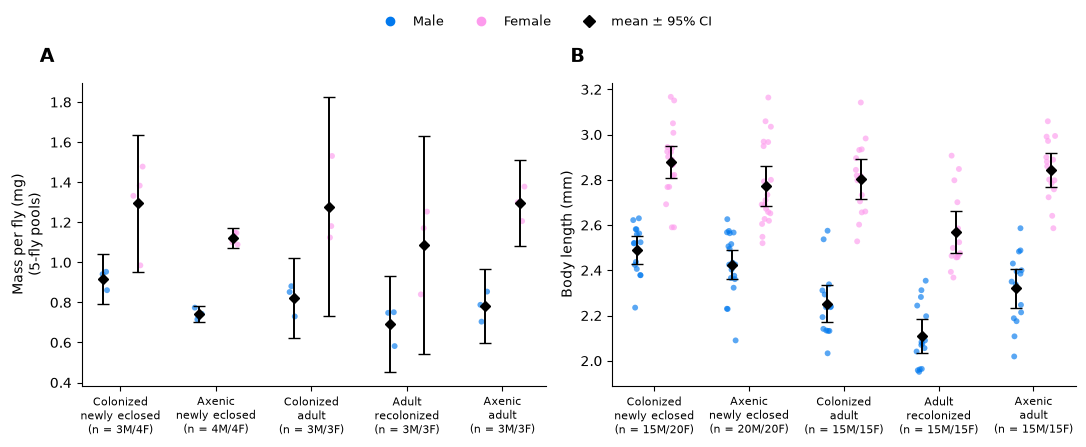

In [2]:
# ============================================================================
# FIGURE uses weight_data / length_data defined above
# ============================================================================

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'          # keep SVG text editable
matplotlib.rcParams['font.family'] = ['Liberation Sans', 'Arimo', 'DejaVu Sans']
import matplotlib.pyplot as plt

ORDER = ['NEC', 'NEA', 'CA', 'CAA', 'AA']             # display order
LABELS = {'NEC': 'Colonized\nnewly eclosed', 'NEA': 'Axenic\nnewly eclosed',
          'CA': 'Colonized\nadult', 'CAA': 'Adult\nrecolonized', 'AA': 'Axenic\nadult'}
COLORS = {'Male': '#0279EE', 'Female': '#FD9BED'}

rng = np.random.default_rng(42)                        # fixed seed = reproducible jitter
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

for ax, dat, ylab, panel in [
    (axes[0], weight_data, 'Mass per fly (mg)\n(5-fly pools)', 'A'),
    (axes[1], length_data, 'Body length (mm)', 'B'),
]:
    xpos = 0
    ticks, ticklabels = [], []
    for grp in ORDER:
        ns = {}
        for sex, dx in [('Male', -0.18), ('Female', 0.18)]:
            vals = np.asarray(dat[grp][sex], dtype=float)
            ns[sex] = len(vals)
            # jittered individual data points
            x = xpos + dx + rng.uniform(-0.055, 0.055, len(vals))
            ax.scatter(x, vals, s=18, alpha=0.65, color=COLORS[sex], edgecolors='none')
            # mean +/- 95% CI (t-based), computed from the data above
            m = vals.mean()
            ci = stats.t.ppf(0.975, len(vals) - 1) * vals.std(ddof=1) / np.sqrt(len(vals)) #interval estimate for the mean, and its width depends on both SD and sample size.
            ax.errorbar(xpos + dx, m, yerr=ci, fmt='D', color='black', markersize=5,
                        capsize=4, linewidth=1.4, zorder=5)
        ticks.append(xpos)
        ticklabels.append(f"{LABELS[grp]}\n(n = {ns['Male']}M/{ns['Female']}F)")
        xpos += 1
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticklabels, fontsize=8)
    ax.set_ylabel(ylab)
    ax.text(-0.09, 1.07, panel, transform=ax.transAxes, fontsize=14, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

handles = [plt.Line2D([], [], marker='o', ls='', color=COLORS[s], label=s) for s in ['Male', 'Female']]
handles.append(plt.Line2D([], [], marker='D', ls='', color='black', label='mean ± 95% CI'))
fig.legend(handles=handles, frameon=False, loc='upper center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.show()
fig.savefig('figure_mass_length.png', dpi=200)
# fig.savefig('figure_mass_length.svg')
print('Saved: figure_mass_length.png, figure_mass_length.svg')


In [8]:
# ============================================================================
# I need table
# ============================================================================

from itertools import combinations

def cohen_d(a, b):
    na, nb = len(a), len(b)
    s = np.sqrt(((na-1)*np.var(a, ddof=1) + (nb-1)*np.var(b, ddof=1)) / (na+nb-2))
    return (np.mean(a) - np.mean(b)) / s

def welch_ci(a, b, conf=0.95):
    va, vb = np.var(a, ddof=1)/len(a), np.var(b, ddof=1)/len(b)
    diff = np.mean(a) - np.mean(b)
    se = np.sqrt(va + vb)
    dfw = (va + vb)**2 / (va**2/(len(a)-1) + vb**2/(len(b)-1))
    tc = stats.t.ppf(1-(1-conf)/2, dfw)
    return diff, diff-tc*se, diff+tc*se

def holm(pvals):
    p = np.asarray(pvals, float); order = np.argsort(p); m = len(p)
    adj = np.empty(m); running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (m-rank)*p[idx])
        adj[idx] = min(1.0, running)
    return adj

ORDER = ['NEC', 'NEA', 'CA', 'CAA', 'AA']
ADULTS = ['CA', 'CAA', 'AA']
NEWLY = ['NEC', 'NEA']

# --- 1. descriptives + Shapiro-Wilk per cell -------------------------------
desc_rows = []
for name, dat in [('length_mm', length_data), ('mass_mg_pool5', weight_data)]:
    for g in ORDER:
        for sex in ['Male', 'Female']:
            x = np.asarray(dat[g][sex], dtype=float)
            W, p_norm = stats.shapiro(x) if len(x) >= 3 else (np.nan, np.nan)
            desc_rows.append({'measure': name, 'group': g, 'sex': sex, 'n': len(x),
                              'mean': x.mean(), 'sd': x.std(ddof=1) if len(x) > 1 else np.nan,
                              'sem': x.std(ddof=1)/np.sqrt(len(x)) if len(x) > 1 else np.nan,
                              'shapiro_W': W, 'shapiro_p': p_norm})
desc_df = pd.DataFrame(desc_rows)
desc_df.to_csv('body_size_descriptives.csv', index=False)

# --- 2. Levene assumption checks -------------------------------------------
lev_rows = []
for name, dat in [('length_mm', length_data), ('mass_mg_pool5', weight_data)]:
    for sex in ['Male', 'Female']:
        samps = [np.asarray(dat[g][sex], dtype=float) for g in ADULTS]
        L, p_l = stats.levene(*samps, center='median')
        lev_rows.append({'measure': name, 'group': f'adults_{sex}',
                         'test': 'Levene_median_centered', 'stat': L, 'p': p_l})
lev_df = pd.DataFrame(lev_rows)
lev_df.to_csv('body_size_assumptions.csv', index=False)

# --- 3. sex contrasts --------------------------------------------------------
sex_rows = []
for name, dat in [('length_mm', length_data), ('mass_mg_pool5', weight_data)]:
    for g in ORDER:
        m = np.asarray(dat[g]['Male'], dtype=float)
        f = np.asarray(dat[g]['Female'], dtype=float)
        t, p_t = stats.ttest_ind(f, m, equal_var=False)
        u, p_u = stats.mannwhitneyu(f, m, alternative='two-sided')
        diff, lo, hi = welch_ci(f, m)
        sex_rows.append({'measure': name, 'group': g, 'comparison': 'Female vs Male',
                         'n_female': len(f), 'n_male': len(m),
                         'mean_female': f.mean(), 'mean_male': m.mean(),
                         'welch_t': t, 'p_welch': p_t, 'mannwhitney_U': u, 'p_U': p_u,
                         'cohens_d': cohen_d(f, m), 'mean_diff_F_minus_M': diff,
                         'ci95_lo': lo, 'ci95_hi': hi})
sex_df = pd.DataFrame(sex_rows)
sex_df.to_csv('body_size_sex_contrasts.csv', index=False)

# --- 4. omnibus tests --------------------------------------------------------
om_rows = []
for name, dat in [('length_mm', length_data), ('mass_mg_pool5', weight_data)]:
    for age, grps in [('newly_eclosed', NEWLY), ('adult', ADULTS)]:
        for sex in ['Male', 'Female']:
            samps = {g: np.asarray(dat[g][sex], dtype=float) for g in grps}
            H, p_kw = stats.kruskal(*samps.values())
            F, p_an = stats.f_oneway(*samps.values())
            allv = np.concatenate(list(samps.values()))
            ss_tot = ((allv - allv.mean())**2).sum()
            eta2 = sum(len(v)*(v.mean()-allv.mean())**2 for v in samps.values()) / ss_tot
            om_rows.append({'measure': name, 'age': age, 'sex': sex,
                            'groups': '+'.join(grps),
                            'n_per_group': '+'.join(str(len(samps[g])) for g in grps),
                            'kruskal_H': H, 'p_kruskal': p_kw,
                            'anova_F': F, 'p_anova': p_an, 'eta_squared': eta2})
om_df = pd.DataFrame(om_rows)
om_df.to_csv('body_size_omnibus.csv', index=False)

# --- 5. Holm-corrected pairwise Welch t -------------------------------------
pw_rows = []
for name, dat in [('length_mm', length_data), ('mass_mg_pool5', weight_data)]:
    for age, grps in [('newly_eclosed', NEWLY), ('adult', ADULTS)]:
        for sex in ['Male', 'Female']:
            samps = {g: np.asarray(dat[g][sex], dtype=float) for g in grps}
            pv, rows = [], []
            for g1, g2 in combinations(grps, 2):
                t, p = stats.ttest_ind(samps[g1], samps[g2], equal_var=False)
                pv.append(p)
                rows.append((g1, g2, t, p, cohen_d(samps[g1], samps[g2]), len(samps[g1]), len(samps[g2])))
            for (g1, g2, t, p, d, n1, n2), ph in zip(rows, holm(pv)):
                pw_rows.append({'measure': name, 'age': age, 'sex': sex,
                                'comparison': f'{g1} vs {g2}',
                                'n1': n1, 'n2': n2, 'welch_t': t, 'p_raw': p,
                                'p_holm': ph, 'cohens_d': d,
                                'significant_holm_0.05': ph < 0.05})
pw_df = pd.DataFrame(pw_rows)
pw_df.to_csv('body_size_pairwise_holm.csv', index=False)

print(f'Saved 5 CSVs:')
print(f'  body_size_descriptives.csv    ({len(desc_df)} rows)')
print(f'  body_size_assumptions.csv     ({len(lev_df)} rows)')
print(f'  body_size_sex_contrasts.csv   ({len(sex_df)} rows)')
print(f'  body_size_omnibus.csv         ({len(om_df)} rows)')
print(f'  body_size_pairwise_holm.csv   ({len(pw_df)} rows)')


Saved 5 CSVs:
  body_size_descriptives.csv    (20 rows)
  body_size_assumptions.csv     (4 rows)
  body_size_sex_contrasts.csv   (10 rows)
  body_size_omnibus.csv         (8 rows)
  body_size_pairwise_holm.csv   (16 rows)
